#### Can You Find the Most Profitable Products?

A retail superstore has years of sales data, but which products are actually making money? Which categories and regions perform best? And are some products selling well while quietly losing money?

In this project, I’ll explore the data using Python and Pandas to find the answers and turn the numbers into real business insights.

Dataset: Superstore Sales (Kaggle)

Tools: Python, Pandas, Matplotlib, Seaborn

### Step 1 Setup

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 25)

### Step 2 loading Data

In [4]:
df = pd.read_csv(r"C:\Users\User\Downloads\superstore-profitability-analysis\superstore-profitability-analysis\data\raw\Sample - Superstore.csv", encoding="latin-1")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.tail()

Rows: 9994, Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


### Step 3 : Exploring the Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Step 4 : Cleaning the Dataset

In [7]:
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

# Converting the order date to a proper datatime type
df["Order Date"] = pd.to_datetime(df["Order Date"])

Missing values:
 0
Duplicate rows: 0


### Step 5 : Most Profitable Category/Sub Category

In [8]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [9]:
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)
subcategory_profit

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

### Step 6 Best Performing Region

In [10]:
region_summary = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).round(2)

region_summary["Profit_Margin_%"] = (region_summary["Total_Profit"] / region_summary["Total_Sales"] * 100).round(2)
region_summary.sort_values("Total_Profit", ascending=False)

,Total_Sales,Total_Profit,Profit_Margin_%
Region,,,
West,725457.82,108418.45,14.94
East,678781.24,91522.78,13.48
South,391721.90,46749.43,11.93
Central,501239.89,39706.36,7.92


### Step 7 Mystery: High Sales, Low/Negative Profit

In [11]:
product_summary = df.groupby("Product Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Discount=("Discount", "mean")
).reset_index()

product_summary["Profit_Margin_%"] = (product_summary["Total_Profit"] / product_summary["Total_Sales"] * 100).round(1)

mystery = product_summary[product_summary["Total_Sales"] > 10000].sort_values("Profit_Margin_%").head(10)
mystery

,Product Name,Total_Sales,Total_Profit,Avg_Discount,Profit_Margin_%
475,Cubify CubeX 3D Printer Double Head Print,11099.9630,-8.879970e+03,0.533333,-80.0
985,Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4.589973e+03,0.400000,-27.3
683,GBC DocuBind P400 Electric Binding System,17965.0680,-1.878166e+03,0.450000,-10.5
444,Cisco TelePresence System EX90 Videoconferenci...,22638.4800,-1.811078e+03,0.500000,-8.0
1043,Martin Yale Chadless Opener Electric Letter Op...,16656.2000,-1.299184e+03,0.100000,-7.8
1351,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.9656,-6.695448e+02,0.234000,-4.3
368,Bretford Rectangular Conference Table Tops,12995.2915,-3.272331e+02,0.245833,-2.5
813,High Speed Automatic Electric Letter Opener,17030.3120,-2.620048e+02,0.066667,-1.5
786,HON 5400 Series Task Chairs for Big and Tall,21870.5760,5.684342e-14,0.200000,0.0
498,DMI Eclipse Executive Suite Bookcases,11046.6090,9.017640e+01,0.183333,0.8


In [12]:
df["Discount_Bin"] = pd.cut(df["Discount"], bins=[-0.01, 0, 0.2, 0.4, 0.6, 1.0])
discount_profit = df.groupby("Discount_Bin", observed=True)["Profit"].mean().round(2)
discount_profit

Discount_Bin
(-0.01, 0.0]     66.90
(0.0, 0.2]       26.50
(0.2, 0.4]      -77.86
(0.4, 0.6]     -134.62
(0.6, 1.0]      -98.35
Name: Profit, dtype: float64

In [13]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Discount_Bin']


Step 8  Visualization 1: Profit by Sub-Category

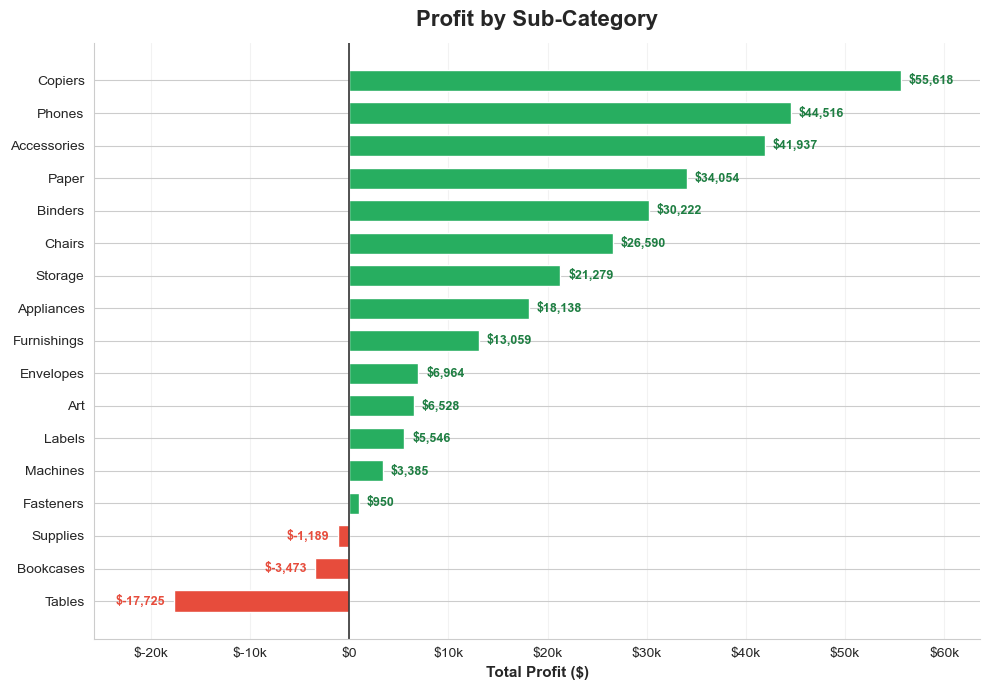

In [14]:
subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values()

colors = ["#e74c3c" if v < 0 else "#27ae60" for v in subcat]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    subcat.index,
    subcat.values,
    color=colors,
    edgecolor="white",
    height=0.65
)

for bar, val in zip(bars, subcat):
    y = bar.get_y() + bar.get_height() / 2
    x = val - 800 if val < 0 else val + 800

    ax.text(
        x,
        y,
        f"${val:,.0f}",
        va="center",
        ha="right" if val < 0 else "left",
        fontsize=9,
        color="#e74c3c" if val < 0 else "#1e7e42",
        fontweight="bold"
    )

ax.axvline(0, color="#333333", linewidth=1.2)

ax.set_title(
    "Profit by Sub-Category",
    fontsize=16,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Total Profit ($)",
    fontsize=11,
    fontweight="bold"
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${x/1000:.0f}k" if x else "$0"
    )
)

ax.set_xlim(
    subcat.min() - 8000,
    subcat.max() + 8000
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Visualization 1
Tables, Bookcases, and Supplies are the only sub-categories with negative total profit, while the remaining sub-categories are profitable.

Step 9 Visualization 2: Sales vs Profit Margin

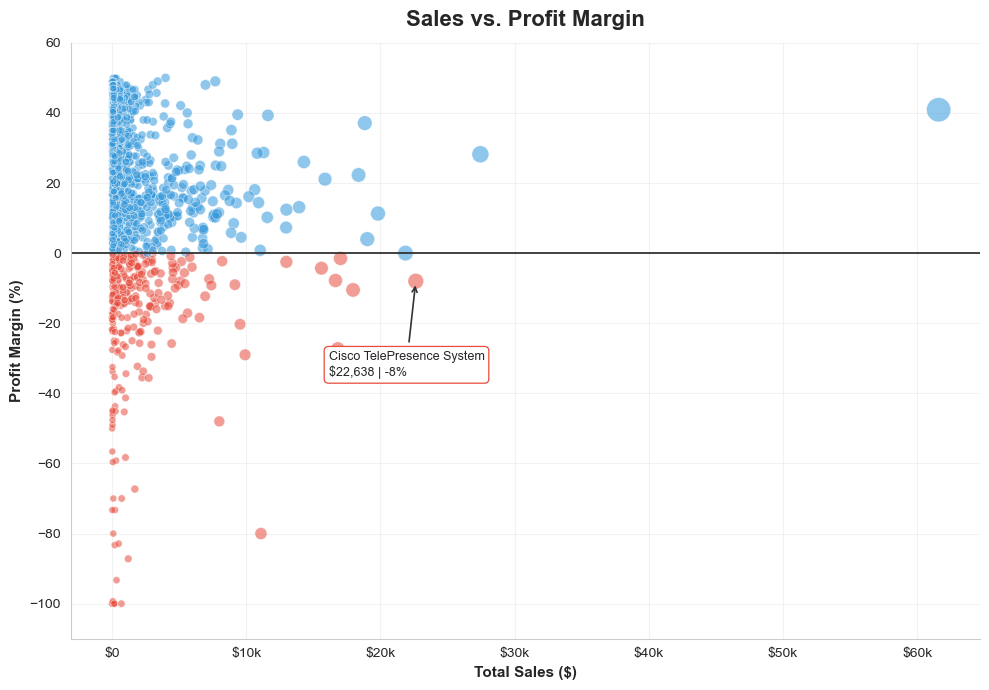

In [15]:
Y_FLOOR = -100

df = product_summary.copy()
df["Margin"] = df["Profit_Margin_%"].clip(lower=Y_FLOOR)

colors = df["Profit_Margin_%"].map(
    lambda x: "#3498db" if x >= 0 else "#e74c3c"
)

sizes = (
    df["Total_Sales"] / df["Total_Sales"].max() * 280 + 25
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    df["Total_Sales"],
    df["Margin"],
    c=colors,
    s=sizes,
    alpha=0.55,
    edgecolors="white",
    linewidth=0.5
)

ax.axhline(0, color="#333333", linewidth=1.3)

ax.set_title(
    "Sales vs. Profit Margin",
    fontsize=16,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Total Sales ($)",
    fontsize=11,
    fontweight="bold"
)

ax.set_ylabel(
    "Profit Margin (%)",
    fontsize=11,
    fontweight="bold"
)

red = product_summary[
    product_summary["Profit_Margin_%"] < 0
]

worst = red.loc[
    red["Total_Sales"].idxmax()
]

ax.annotate(
    f"{worst['Product Name'][:25]}\n"
    f"${worst['Total_Sales']:,.0f} | "
    f"{worst['Profit_Margin_%']:.0f}%",
    xy=(
        worst["Total_Sales"],
        worst["Profit_Margin_%"]
    ),
    xytext=(
        worst["Total_Sales"] - 6500,
        -35
    ),
    fontsize=9,
    ha="left",
    arrowprops=dict(
        arrowstyle="->",
        color="#333333",
        lw=1.2,
        shrinkA=3,
        shrinkB=3
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="#e74c3c",
        lw=0.9
    )
)

ax.set_ylim(Y_FLOOR - 10, 60)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${x/1000:.0f}k" if x else "$0"
    )
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    alpha=0.25,
    linewidth=0.8
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Visualization 2
Higher sales do not always lead to higher profit margins, with some high-selling products showing negative margins.

## Step 10 Business Recommendations
1. Control discounting on Tables. Avoid giving heavy discounts, as they can quickly reduce the already weak profit margins.

2. Re-price or reconsider the Tables sub-category. Tables is the only sub-category showing a significant overall loss of $17,725.

3. Improve Central's profitability. Central has strong sales but lower profitability than West. It should look at what is working well in West and apply similar strategies where appropriate.

4. Focus on profit, not just sales. High sales do not always mean high profit. A product can sell well but still lose money if discounts and costs are too high.

### Conclusion

High sales don't always mean high profit. Tables is losing money, while West is performing better than the other regions. The analysis also shows that heavy discounting can make even high-selling products unprofitable. So, when evaluating business performance, it's important to look at profit and margins, not just sales.